In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_and_combine_dtu, add_qd_gridlines_cs, load_cdf_file, mjd2000_to_datetime, gd2gc, my_chaos
from chaosmagpy import load_CHAOS_matfile
from chaosmagpy.data_utils import mjd2000, load_RC_datfile
import glob

RE = 6371.2e3
RI = RE + 110e3

theta0=0.25 # for j_G matrix singularity limit

Epoch = 2025.

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
#L, W, Lres, Wres = 2500e3,3500e3,45,35
L, W, Lres, Wres = 2500e3,3500e3,100.0e3,100.0e3

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,89))

# Define meridian
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*50

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [18]:
folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'SUM1']
stations = np.load('stations_dtu.npy', allow_pickle=True)
times = np.load('concurrent_times_dtu_minute.npy',allow_pickle=True)

In [ ]:
df_mag = load_and_combine_dtu('20260525', folders, base_dir='dtu_downloads/yearly_BASELINE')

In [20]:
df1 = df_mag[df_mag['time']==datetime(2026,5,11,2,12,0)]
df2 = df_mag[df_mag['time']==datetime(2026,5,11,2,17,0)]
df3 = df_mag[df_mag['time']==datetime(2026,5,11,2,22,0)]

In [21]:
df3

,time,X,Y,Z,t_mjd,iaga
130878,2026-05-11 02:22:00,53.116938,5.686554,46.146128,9627.098611,GDH
130879,2026-05-11 02:22:00,-112.104759,45.095243,-5.278443,9627.098611,KUL
130880,2026-05-11 02:22:00,46.546511,30.303344,-15.183337,9627.098611,KUV
130881,2026-05-11 02:22:00,11.119468,1.965772,-46.709524,9627.098611,NAQ
130882,2026-05-11 02:22:00,NaN,NaN,-41.772299,9627.098611,NRD
130883,2026-05-11 02:22:00,NaN,NaN,-33.083412,9627.098611,PIF
130884,2026-05-11 02:22:00,16.222781,4.703161,13.953322,9627.098611,SCO
130885,2026-05-11 02:22:00,-160.314239,-13.456881,35.085361,9627.098611,SKT
130886,2026-05-11 02:22:00,47.256143,20.271441,-0.431203,9627.098611,SUM


In [22]:
x, y, z, t_mjd = load_cdf_file('dtu_downloads/PIF4/2026/PIF4_20260511.cdf')
t = mjd2000_to_datetime(t_mjd)
df_PIF = pd.DataFrame({'X':x, 'Y':y, 'Z':z, 'time':t, 't_mjd':t_mjd})

x, y, z, t_mjd = load_cdf_file('dtu_downloads/NRD2/2026/NRD2_20260511.cdf')
t = mjd2000_to_datetime(t_mjd)
df_NRD = pd.DataFrame({'X':x, 'Y':y, 'Z':z, 'time':t, 't_mjd':t_mjd})

In [23]:
df_bias = pd.read_pickle('data_frames/bias_ezie.pkl')
# Load CHAOS model
model_c = load_CHAOS_matfile(glob.glob('CHAOS-*.mat')[0])
rc = load_RC_datfile(glob.glob('RC*.dat')[0])

In [24]:
# geocentric coordinates of station for CHAOS use
r, colat_gc, Z_gc, X_gc = gd2gc(81.60, 0, df_NRD['X'].values, df_NRD['Z'].values) # using 0km height (Maries recommendation)
lon_gc = 343.33
Y_gc = df_NRD['Y'].values # same in gd and gc

# Run CHAOS on hourly time steps
time_hourly = df_NRD['t_mjd'].values[::3600]
df_chaos_NRD = my_chaos(
    model_c, rc,
    colat_gc * np.ones(time_hourly.size),
    lon_gc   * np.ones(time_hourly.size),
    r        * np.ones(time_hourly.size),
    time_hourly, internal=True
)[['time', 'Bx_gd', 'By_gd', 'Bz_gd']]  # drop unused CHAOS output columns early

# geocentric coordinates of station for CHAOS use
r, colat_gc, Z_gc, X_gc = gd2gc(76.54, 0, df_PIF['X'].values, df_PIF['Z'].values) # using 0km height (Maries recommendation)
lon_gc = 291.18
Y_gc = df_PIF['Y'].values # same in gd and gc

# Run CHAOS on hourly time steps
time_hourly = df_PIF['t_mjd'].values[::3600]
df_chaos_PIF = my_chaos(
    model_c, rc,
    colat_gc * np.ones(time_hourly.size),
    lon_gc   * np.ones(time_hourly.size),
    r        * np.ones(time_hourly.size),
    time_hourly, internal=True
)[['time', 'Bx_gd', 'By_gd', 'Bz_gd']]  # drop unused CHAOS output columns early

Computing core field.
Computing crustal field up to degree 110.
Computing field due to external sources, incl. induced field: GSM.
Computing field due to external sources, incl. induced field: SM.
Computing core field.
Computing crustal field up to degree 110.
Computing field due to external sources, incl. induced field: GSM.
Computing field due to external sources, incl. induced field: SM.


In [ ]:
df_NRD['dX'] = df_NRD['X'] - df_chaos_NRD['Bx_gd'].mean() - df_bias.loc['NRD2']['bias_x']
df_PIF['dX'] = df_PIF['X'] - df_chaos_PIF['Bx_gd'].mean() - df_bias.loc['PIF4']['bias_x']


In [ ]:
df1.loc[df1['iaga'] == 'NRD', 'X'] = df_NRD[df_NRD['time']==df1['time'].mean()]['dX'].values[0]
df2.loc[df2['iaga'] == 'NRD', 'X'] = df_NRD[df_NRD['time']==df2['time'].mean()]['dX'].values[0]
df3.loc[df3['iaga'] == 'NRD', 'X'] = df_NRD[df_NRD['time']==df3['time'].mean()]['dX'].values[0]

df1.loc[df1['iaga'] == 'PIF', 'X'] = df_PIF[df_PIF['time']==df1['time'].mean()]['dX'].values[0]
df2.loc[df2['iaga'] == 'PIF', 'X'] = df_PIF[df_PIF['time']==df2['time'].mean()]['dX'].values[0]
df3.loc[df3['iaga'] == 'PIF', 'X'] = df_PIF[df_PIF['time']==df3['time'].mean()]['dX'].values[0]

In [27]:
ss = slice(0, -1, 2) # downsample for vector plots
la, lo = grid.lat_mesh[ss, ss], grid.lon_mesh[ss, ss]

# matrices that calculate currents (for plotting vectors):
Gej, Gnj = get_SECS_J_G_matrices(la, lo, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI)
Gej_grid, Gnj_grid = get_SECS_J_G_matrices(grid.lat_mesh, grid.lon_mesh, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI)
# and magnetic field on ground (evaluated on the full "mesh" grid, not downsampled):
GeB, GnB, GuB = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon)

In [28]:
stations = df1['iaga'].unique()
df_loc = pd.read_csv('dtu_stations.csv')
df_loc = df_loc[df_loc['IAGA'].isin(stations)]
df_loc = df_loc.sort_values(by='IAGA')
lon_mag = df_loc['lon_gd'].values
lat_mag = df_loc['lat_gd'].values

In [29]:
i = 0
for df in [df1,df2,df3]:
    i += 1

    #lon_mag, lat_mag = (df1['GEOLON'].values+180)%360-180, df1['GEOLAT'].values
    xi_mag, eta_mag = projection.geo2cube(lon_mag, lat_mag)

    GeB_mag, GnB_mag, GuB_mag = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)
    Be_mag, Bn_mag, Bu_mag = df['Y'].values, df['X'].values, -df['Z'].values #note sign change on z component

    # first we stack the G matrices and data vectors.
    depth = 350e3 # depth where Br = 0 [m]
    GeB_mirror,     GnB_mirror,     GuB_mirror     = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
    GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag      , lon_mag      , RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)

    # G matrix for the mirror current method:
    G_mirror = np.vstack((GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror)) # shape: (3*N, grid.size)
    d = np.hstack((Be_mag, Bn_mag, Bu_mag)) * 10**(-9)   # shape: (3*N)

    # Approach number 2: East-west minimization
    Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid) # get matrices that calculate MAGNETIC eastward and northward components of gradient
    LTL = LTLe

    T0, T1 = 5e-24, 1e-21 # regularization parameters
    R = T0 * np.eye(grid.size) + T1 * LTL # regularization matrix

    # using inversion approach (2):
    GTG_mirror, GTd_mirror = G_mirror.T.dot(G_mirror), G_mirror.T.dot(d) # we multiply the set of equations by G_mirror transpose
    I_mirror = np.linalg.lstsq(GTG_mirror + R, GTd_mirror, rcond = 0)[0]
    if i == 1:
        I_mirror1 = I_mirror
        Bu_mag1 = Bu_mag
    elif i == 2:
        I_mirror2 = I_mirror
        Bu_mag2 = Bu_mag
    if i == 3:
        I_mirror3 = I_mirror
        Bu_mag3 = Bu_mag


gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.
gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.
gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.


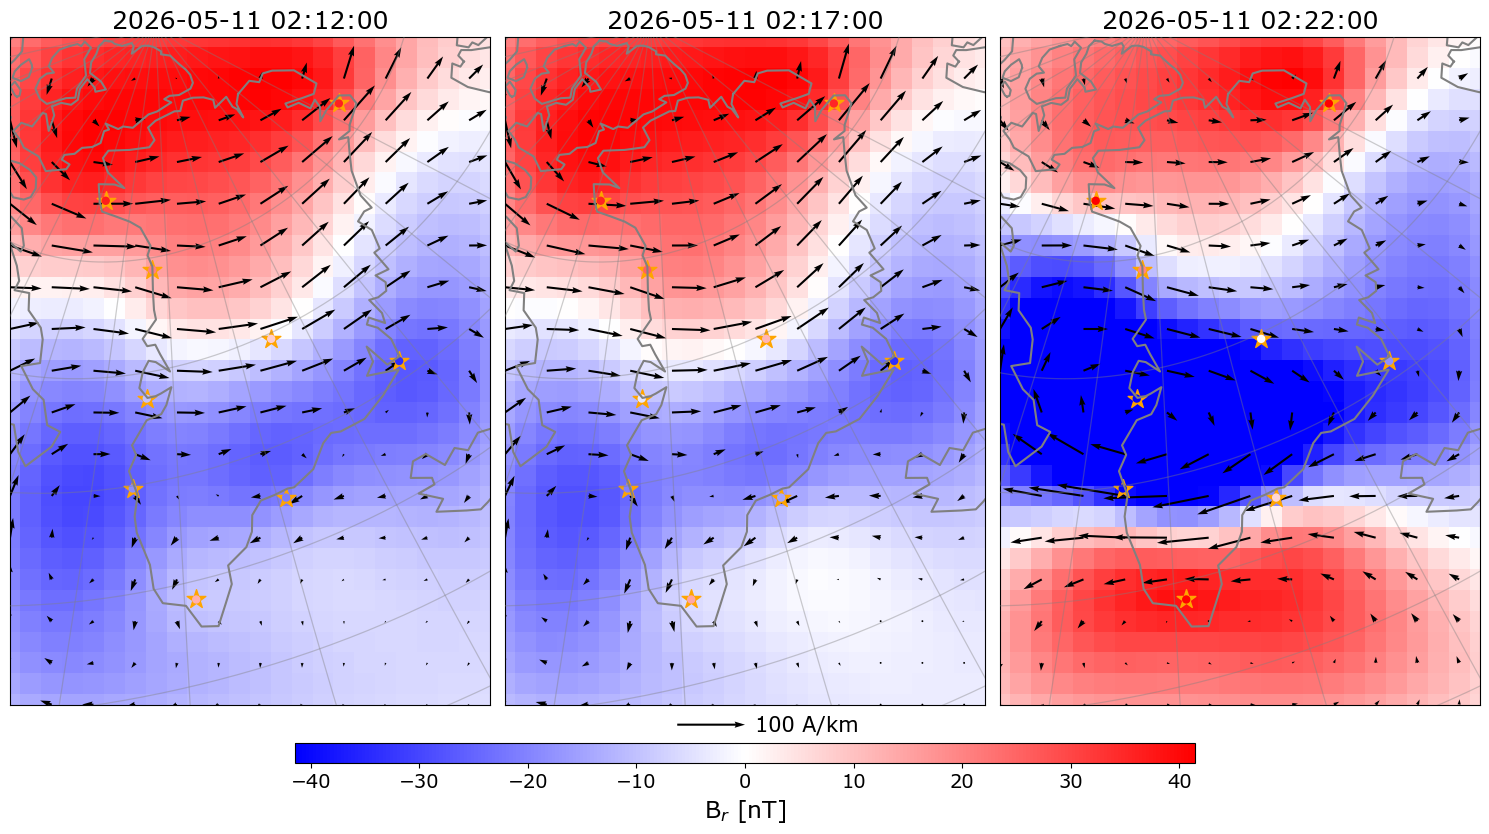

In [30]:
# Plot the original and the solutions
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(15, 8))
fig.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.14, wspace=0.25)

csaxes = [CSplot(ax, grid, gridtype=None) for ax in axes.flatten()]

# --- Subplot 0 ---
Be, Bn, Bu = (GeB.dot(I_mirror1).reshape(grid.lat_mesh.shape)*1e9,
              GnB.dot(I_mirror1).reshape(grid.lat_mesh.shape)*1e9,
              GuB.dot(I_mirror1).reshape(grid.lat_mesh.shape)*1e9)
je, jn = Gej.dot(I_mirror1).reshape(la.shape)*1000, Gnj.dot(I_mirror1).reshape(la.shape)*1000
qv0 = csaxes[0].quiver(je, jn, lo, la)
pm0 = csaxes[0].pcolormesh(grid.lon_mesh, grid.lat_mesh, Bu,
                            cmap=plt.cm.bwr,
                            vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()), zorder=0)
csaxes[0].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
csaxes[0].ax.scatter(xi_mag, eta_mag, c=Bu_mag1, s=25, cmap=plt.cm.bwr,
                     vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()))

# --- Subplot 1 ---
Be, Bn, Bu = (GeB.dot(I_mirror2).reshape(grid.lat_mesh.shape)*1e9,
              GnB.dot(I_mirror2).reshape(grid.lat_mesh.shape)*1e9,
              GuB.dot(I_mirror2).reshape(grid.lat_mesh.shape)*1e9)
je, jn = Gej.dot(I_mirror2).reshape(la.shape)*1000, Gnj.dot(I_mirror2).reshape(la.shape)*1000
qv1 = csaxes[1].quiver(je, jn, lo, la)
pm1 = csaxes[1].pcolormesh(grid.lon_mesh, grid.lat_mesh, Bu,
                            cmap=plt.cm.bwr,
                            vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()), zorder=0)
csaxes[1].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
csaxes[1].ax.scatter(xi_mag, eta_mag, c=Bu_mag2, s=25, cmap=plt.cm.bwr,
                     vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()))

# --- Subplot 2 ---
Be, Bn, Bu = (GeB.dot(I_mirror3).reshape(grid.lat_mesh.shape)*1e9,
              GnB.dot(I_mirror3).reshape(grid.lat_mesh.shape)*1e9,
              GuB.dot(I_mirror3).reshape(grid.lat_mesh.shape)*1e9)
je, jn = Gej.dot(I_mirror3).reshape(la.shape)*1000, Gnj.dot(I_mirror3).reshape(la.shape)*1000
qv2 = csaxes[2].quiver(je, jn, lo, la)
pm2 = csaxes[2].pcolormesh(grid.lon_mesh, grid.lat_mesh, Bu,
                            cmap=plt.cm.bwr,
                            vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()), zorder=0)
csaxes[2].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
csaxes[2].ax.scatter(xi_mag, eta_mag, c=Bu_mag3, s=25, cmap=plt.cm.bwr,
                     vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()))

# --- Coastlines ---
for csa in csaxes:
    csa.add_coastlines(color='grey', resolution='110m')

# --- QD gridlines ---
EXTENT = [-90, 10, 53, 85]
for csa in csaxes:
    add_qd_gridlines_cs(
        csa, apex_obj,
        qlat_lines=range(50, 85, 5),
        qlon_lines=range(-60, 100, 10),
        extent=EXTENT,
        lat_color='grey', lon_color='grey',
        linewidth=0.9, alpha=0.4, linestyle='-',
        label_gridlines=False,
    )

# --- Shared colorbar: placed manually, independent of axes layout ---
cbar_ax = fig.add_axes([0.2, 0.01, 0.6, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(pm0, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('B$_r$ [nT]', size=17)

# --- Shared quiverkey: placed in figure coordinates above the colorbar ---
csaxes[1].ax.quiverkey(qv1, X=0.5, Y=-0.03, U=100,
                        label='100 A/km', labelpos='E', fontproperties={'size': 15})
axes[0].set_title(str(df1['time'].mean()), fontsize=18)
axes[1].set_title(str(df2['time'].mean()), fontsize=18)
axes[2].set_title(str(df3['time'].mean()), fontsize=18)
#fig.suptitle('DTU Maps', fontsize=20)
plt.tight_layout()
plt.show()